In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm

device = torch.accelerator.current_accelerator() if torch.accelerator.is_available() else torch.device("cpu")

epochs = 10
batch_size = 1024
learning_rate = 1e-3

shift = 3
max_chars = 150
eval_samples = 1000

## Чтение и исследование данных

In [2]:
data = pd.read_parquet("English_Sentences_Clean.parquet")

data

,english_sentence
0,politicians do not have permission to do what ...
1,"I'd like to tell you about one such child,"
2,This percentage is even greater than the perce...
3,what we really mean is that they're bad at not...
4,.The ending portion of these Vedas is called U...
...,...
124307,Examples of art deco construction can be found...
124308,and put it in our cheeks.
124309,"As for the other derivatives of sulphur , the ..."
124310,its complicated functioning is defined thus in...


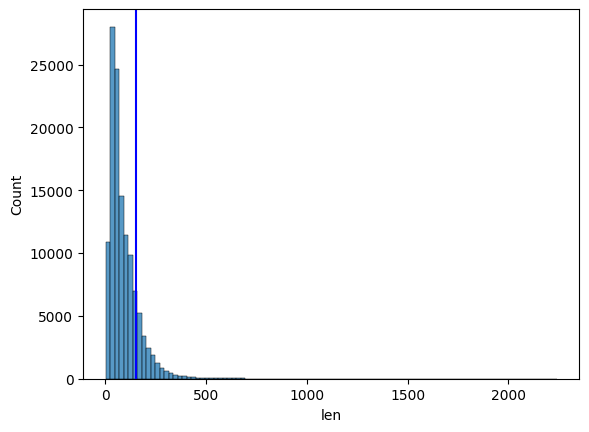

In [3]:
data["len"] = data["english_sentence"].astype(str).str.len()

sns.histplot(data["len"], bins=100)
plt.axvline(x=max_chars, color="blue")
plt.show()

In [4]:
data = data[data["len"] <= max_chars]

In [5]:
from collections import Counter


all_text = ''.join(data.fillna('').astype(str).to_numpy().ravel())
symbol_counts = Counter(all_text)

symbol_counts

Counter({' ': 1131632,
         'e': 632899,
         'a': 470068,
         't': 464755,
         'i': 393781,
         'o': 392879,
         'n': 378269,
         's': 341414,
         'r': 325917,
         'h': 275605,
         'l': 211078,
         'd': 202936,
         'c': 149476,
         'u': 147361,
         'm': 131723,
         'f': 113027,
         'g': 101300,
         'p': 101188,
         'y': 94045,
         'w': 92526,
         'b': 74409,
         '.': 73922,
         'v': 55322,
         ',': 53435,
         '1': 52453,
         'k': 38779,
         '3': 30783,
         '2': 30658,
         '4': 29891,
         '5': 25938,
         '0': 25388,
         'I': 24742,
         'T': 23357,
         '6': 22830,
         '9': 21748,
         '7': 20184,
         '8': 19731,
         'A': 19110,
         '-': 17008,
         'S': 16372,
         "'": 15945,
         'B': 13397,
         'M': 10215,
         'R': 9926,
         'H': 9790,
         'C': 9565,
         'j': 9091

## Создание датасета (токенизация данных)

In [6]:
from dataHandling import CaesarCipherHandler, MyTokenizer, get_loaders

alphabet = list(symbol_counts.keys())

handler = CaesarCipherHandler(alphabet, shift)
tokenizer = MyTokenizer(alphabet)

train_loader, test_loader = get_loaders(data["english_sentence"], handler, tokenizer, batch_size=batch_size)

![](image.png)

## Создание сети на GRU и тренировка

In [7]:
from gru import GRU

gru = GRU(input_size=len(tokenizer), hidden_size=128, output_size=len(tokenizer))

gru.to(device)

gru_optimizer = optim.Adam(gru.parameters(), lr=learning_rate)
gru_criterion = nn.CrossEntropyLoss()

In [8]:
from trainer import Trainer

gru_trainer = Trainer(gru, gru_criterion, gru_optimizer, device, epoch_amount=epochs)

In [9]:
# gru_trainer.fit(train_loader)

In [10]:
# plt.loglog(gru_trainer.train_loss, label="train")
# plt.legend()
# plt.show()

In [11]:
# gru_trainer.save("gru.pth")

## Создание сети на LSTM и тренировка

In [12]:
from lstm import LSTM

lstm = LSTM(input_size=len(tokenizer), hidden_size=128, output_size=len(tokenizer))

lstm.to(device)

lstm_optimizer = optim.Adam(lstm.parameters(), lr=learning_rate)
lstm_criterion = nn.CrossEntropyLoss()

In [13]:
from trainer import Trainer

lstm_trainer = Trainer(lstm, lstm_criterion, lstm_optimizer, device, epoch_amount=epochs)

In [14]:
# lstm_trainer.fit(train_loader)

In [15]:
# plt.loglog(lstm_trainer.train_loss, label="train")
# plt.legend()
# plt.show()

In [16]:
# lstm_trainer.save("lstm.pth")

## Оценка результатов

In [17]:
gru_trainer.load("gru.pth")

In [18]:
preds = gru_trainer.predict(test_loader)

Predicting:   0%|          | 0/21 [00:00<?, ?it/s]

In [19]:
preds = preds.softmax(dim=2)
preds = preds.argmax(dim=2)
preds = [tokenizer.detokenize(pred) for pred in preds]
preds = [handler.decipher(pred) for pred in preds]
targets = test_loader.dataset.data

gru_preds = pd.DataFrame({"pred": preds, "target": targets})
gru_preds.head()

,pred,target
106931,One thousand prisoners who sat in meditation. ...,One thousand prisoners who sat in meditation.
53217,"But if you look at the spectrum, ...","But if you look at the spectrum,"
55933,And this is very difficult to do ...,And this is very difficult to do
85174,"especially adolescents, ...","especially adolescents,"
93264,Village Panchayats could also determine suits ...,Village Panchayats could also determine suits ...


In [20]:
from metrics import Metrics

metrics = Metrics()
samples = gru_preds.sample(eval_samples)
gru_metrics = metrics.calculate_metrics(samples["pred"], samples["target"])

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Calculating metrics:   0%|          | 0/1000 [00:00<?, ?it/s]

/Users/andrey/Ground/25AIMEPhI/.venv/lib/python3.12/site-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 3-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)
/Users/andrey/Ground/25AIMEPhI/.venv/lib/python3.12/site-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 4-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)
/Users/andrey/Ground/25AIMEPhI/.venv/lib/python3.12/site-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 2-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.


In [30]:
gru_metrics.describe()

,levenshtein_distance,levenshtein_similarity,jaccard_similarity,tfidf_similarity,sequence_matcher,bleu_score,sentence_transformer
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03,1000.000000
mean,85.965000,0.560172,0.991451,0.991849,0.560172,9.120792e-01,0.997061
std,36.081708,0.229901,0.054091,0.059103,0.229901,2.776614e-01,0.019384
min,0.000000,0.051948,0.333333,0.000000,0.051948,1.531972e-231,0.712626
25%,60.000000,0.387097,1.000000,1.000000,0.387097,1.000000e+00,1.000000
50%,94.000000,0.543689,1.000000,1.000000,0.543689,1.000000e+00,1.000000
75%,114.000000,0.750000,1.000000,1.000000,0.750000,1.000000e+00,1.000000
max,146.000000,1.000000,1.000000,1.000000,1.000000,1.000000e+00,1.000000


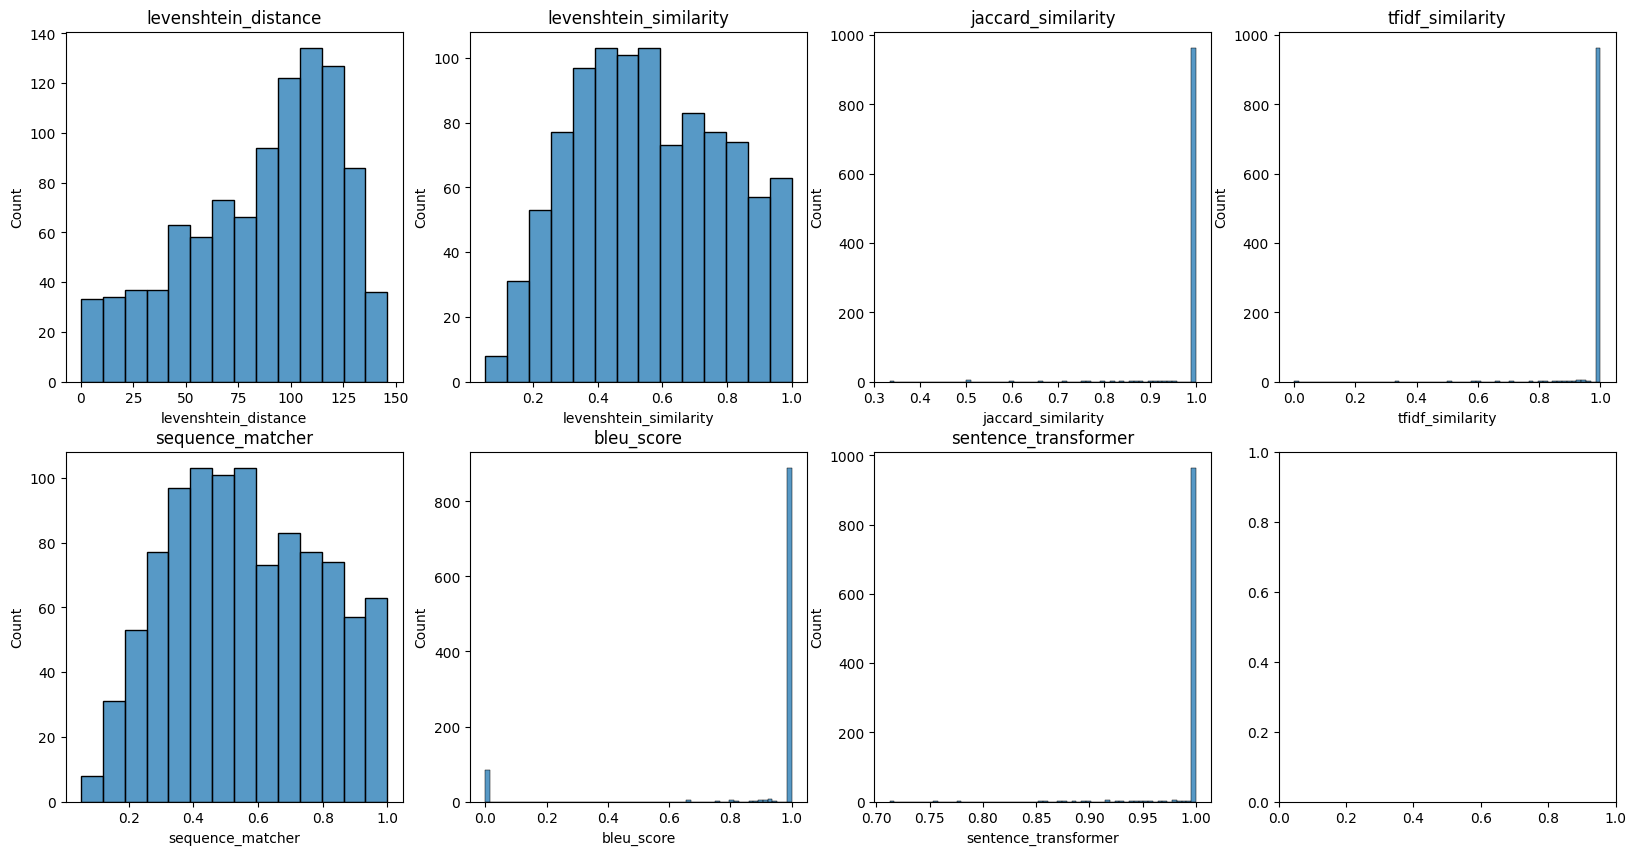

In [22]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))

for i, metric in enumerate(gru_metrics.columns):
    sns.histplot(gru_metrics[metric], ax=axes[i // 4, i % 4])
    axes[i // 4, i % 4].set_title(metric)

plt.show()

In [23]:
lstm_trainer.load("lstm.pth")

In [24]:
preds = lstm_trainer.predict(test_loader)

Predicting:   0%|          | 0/21 [00:00<?, ?it/s]

In [25]:
preds = preds.softmax(dim=2)
preds = preds.argmax(dim=2)
preds = [tokenizer.detokenize(pred) for pred in preds]
preds = [handler.decipher(pred) for pred in preds]
targets = test_loader.dataset.data

lstm_preds = pd.DataFrame({"pred": preds, "target": targets})
lstm_preds.head()

,pred,target
106931,One thousand prisoners who sat in meditation. ...,One thousand prisoners who sat in meditation.
53217,"But if you look at the spectrum, ...","But if you look at the spectrum,"
55933,And this is very difficult to do ...,And this is very difficult to do
85174,"especially adolescents, ...","especially adolescents,"
93264,Village Panchayats could also determine suits ...,Village Panchayats could also determine suits ...


In [26]:
from metrics import Metrics

metrics = Metrics()
samples = lstm_preds.sample(eval_samples)
lstm_metrics = metrics.calculate_metrics(samples["pred"], samples["target"])

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Calculating metrics:   0%|          | 0/1000 [00:00<?, ?it/s]

/Users/andrey/Ground/25AIMEPhI/.venv/lib/python3.12/site-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 4-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)
/Users/andrey/Ground/25AIMEPhI/.venv/lib/python3.12/site-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 3-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)
/Users/andrey/Ground/25AIMEPhI/.venv/lib/python3.12/site-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 2-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.


In [29]:
lstm_metrics.describe()

,levenshtein_distance,levenshtein_similarity,jaccard_similarity,tfidf_similarity,sequence_matcher,bleu_score,sentence_transformer
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03,1000.000000
mean,86.396000,0.554725,0.987796,0.992236,0.554725,8.998305e-01,0.995993
std,37.220324,0.237147,0.059815,0.043074,0.237147,2.881582e-01,0.023095
min,0.000000,0.064516,0.250000,0.336097,0.064516,9.291880e-232,0.683012
25%,60.000000,0.369565,1.000000,1.000000,0.369565,1.000000e+00,1.000000
50%,95.000000,0.536585,1.000000,1.000000,0.536585,1.000000e+00,1.000000
75%,116.000000,0.750000,1.000000,1.000000,0.750000,1.000000e+00,1.000000
max,145.000000,1.000000,1.000000,1.000000,1.000000,1.000000e+00,1.000000


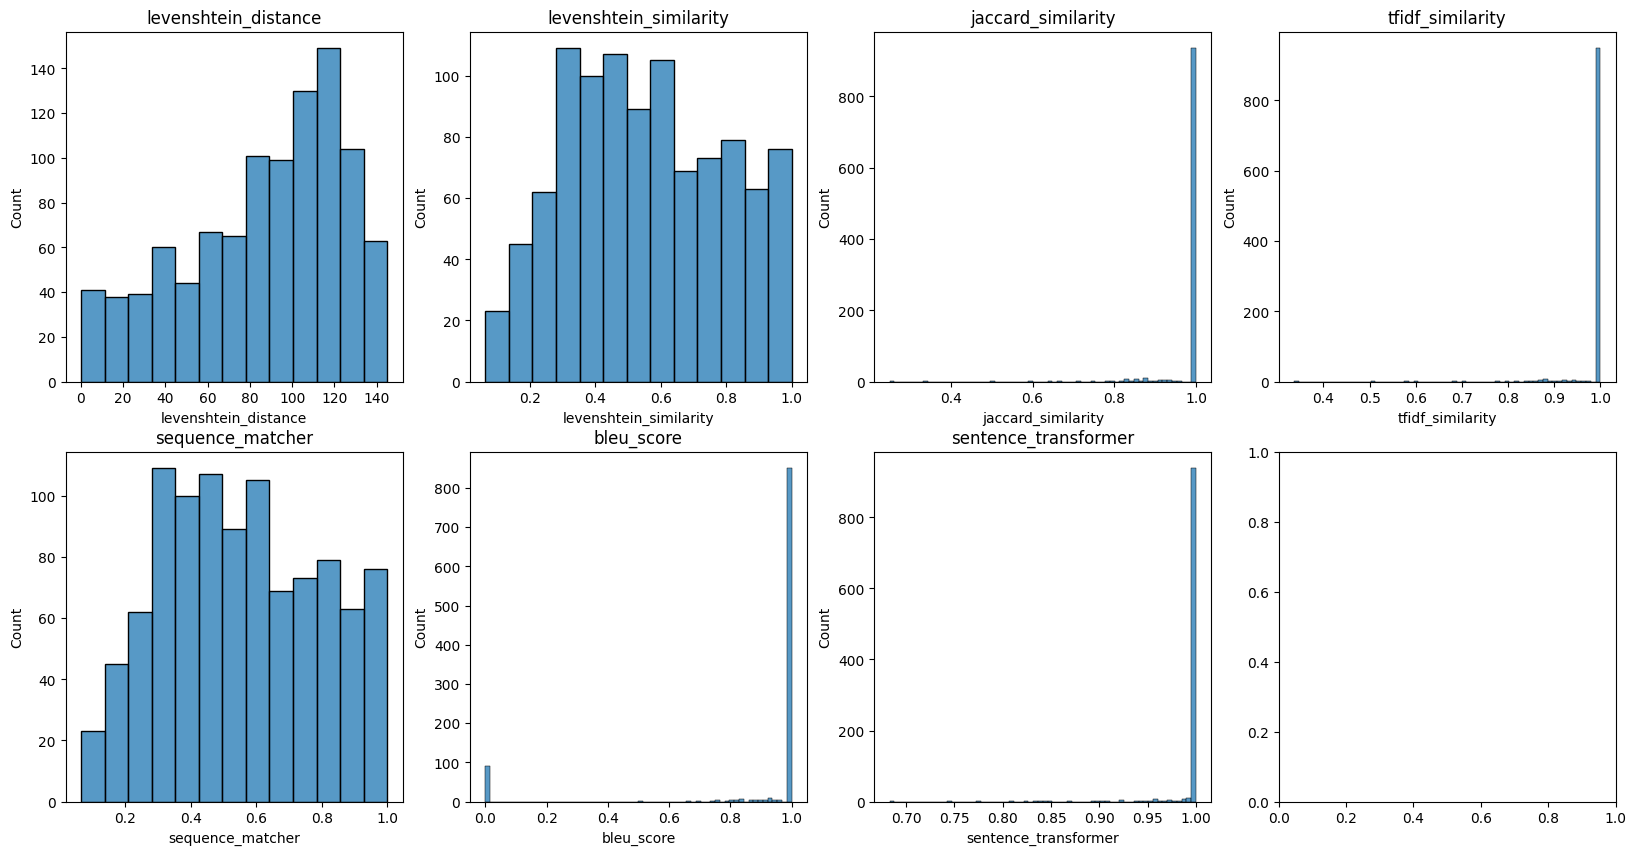

In [28]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))

for i, metric in enumerate(lstm_metrics.columns):
    sns.histplot(lstm_metrics[metric], ax=axes[i // 4, i % 4])
    axes[i // 4, i % 4].set_title(metric)

plt.show()